#A/B тест: Paywall після онбордингу (А vs B "-50%")

##Контекст:
- Група А: стандартний екран підписки $4.99
- Група В: та ж підписка $4.99, але з повідомленням -50%
- Основна метрика: конверсія в покупку (purchase/users)

##Гіпотези:
- Н0: коніерсія в групі В = конверсії в групі А;
- Н1: конверсія в групі В ≠ конверсії в групі А.

Припускаємо, що допоміжні метрики не змінилися, ому рішення приймаємо на основі конверсії.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\ПК\Desktop\ДЗ Тестування АБ\ab_test_data.csv")

df.head,df.shape
#Переконуємось що файл зчитався і ми бачимо колонки

(<bound method NDFrame.head of                                     user_id                   timestamp  \
 0      7f6833e6-1141-4f20-b4b2-f1e31019b1fd  2023-07-04 04:40:55.848109   
 1      e6a6e960-d3f3-4074-a516-ba1e609b211e  2023-07-06 00:26:45.486187   
 2      4d3fbfa5-6847-410a-bac2-477f01d5f400  2023-07-10 20:24:33.639464   
 3      361457d9-a044-48f7-981c-d67dc3861679  2023-07-20 07:04:49.957013   
 4      285cd63d-7d03-427f-a062-1fa2dd2e77d6  2023-07-19 23:27:50.116680   
 ...                                     ...                         ...   
 19993  6763ae9a-515c-473e-af00-0d9c4f6a5bc7  2023-07-06 03:27:37.041104   
 19994  ac5600f2-4d16-4503-b115-f1a96728b6d1  2023-07-03 04:20:48.572143   
 19995  5a8b2630-209b-4d83-b47f-0f3d9dd568a8  2023-07-23 16:23:49.211910   
 19996  b572d68b-26ac-432b-9f88-83e0fdee4ca1  2023-07-03 18:26:20.880675   
 19997  3d313adc-c8d6-43f2-8b4e-e267b194ff78  2023-07-19 13:15:37.562340   
 
       test_group  conversion  
 0              a       

In [18]:
# Приводимо дані до правильних типів

#1) Час у datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

#2) Назви груп в єдиний формат А/В
df["test_group"] = df["test_group"].astype(str).str.upper()

#3) conversion у 0/1 
df["conversion"] = df["conversion"].astype(int)

df.dtypes

user_id               object
timestamp     datetime64[ns]
test_group            object
conversion             int64
dtype: object

In [19]:
# Рахуємо кількість людей, кількість покупок, конверсію, коли йшов тест

# Users = унікальні користувачі
users = df.groupby("test_group")["user_id"].nunique()

# Conversion = сума conversion
conversions = df.groupby("test_group")["conversion"].sum()

# Conversion rate
cr = conversions / users

# Дати тесту
start_ts = df["timestamp"].min()
end_ts = df["timestamp"].max()
duration_days = (end_ts.date() - start_ts.date()).days +1

users, conversions, cr, start_ts, end_ts, duration_days

(test_group
 A    10013
 B     9985
 Name: user_id, dtype: int64,
 test_group
 A    611
 B    889
 Name: conversion, dtype: int64,
 test_group
 A    0.061021
 B    0.089034
 dtype: float64,
 Timestamp('2023-07-03 01:42:34.033708'),
 Timestamp('2023-07-25 01:41:19.152664'),
 23)

In [20]:
# Таблиця звітності. Тут ми отримуємо результати тесту: кількість користувачів, кількість конверсій і конверсію в групах А і В, а також період тесту.
summary = pd.DataFrame({
    "Group": users.index,
    "Users": users.values,
    "Conversions": conversions.reindex(users.index).values,
    "Conversions_rate": (cr.reindex(users.index).values * 100)
})

summary["Conversions_rate"] = summary["Conversions_rate"].round(2).astype(str) + "%"
summary

,Group,Users,Conversions,Conversions_rate
0,A,10013,611,6.1%
1,B,9985,889,8.9%


Обираємо критерій і рахуємо P-value

Для бінарної метрики (конверсії) правильний простий вибір - z-тест для двох часток

- Ми перевіряємо, чи різниця конверсій між А і В "реальна", а не випадкова.
- p_value < 0.05  -  відхиляємо Н0(нульову гіпотезу)
  

In [22]:
from math import sqrt
from scipy.stats import norm

# Витягуємо числа (порядок А,В)
x_A = int(conversions["A"])
n_A = int (users["A"])
x_B = int(conversions["B"])
n_B = int(users["B"])

p_A = x_A / n_A
p_B = x_B / n_B

# pooled proportion
p_pool = (x_A + x_B) / (n_A + n_B)

# standart error
se = sqrt(p_pool * (1 - p_pool) * (1/n_A + 1/n_B))

z_stat = (p_B -p_A) / se
p_value = 2 * (1 - norm.cdf(abs(z_stat)))

# two-sided
alpha = 0.05
reject_h0 = p_value < alpha

p_A, p_B, z_stat, p_value, reject_h0

(0.06102067312493758,
 0.08903355032548824,
 7.519675939906207,
 np.float64(5.484501741648273e-14),
 np.True_)

Статистичний тест

Використано двосторонній z-тест для двох часток (two-proportion z-test).
- Конверсія групи A: 6.10%
- Конверсія групи B: 8.90%
- Різниця: +2.8 п.п.
- z-statistic: 7.52
- p-value: 5.48e-14
Оскільки p-value < 0.05, ми відхиляємо нульову гіпотезу.
Отже, новий дизайн з повідомленням про знижку 50% статистично значуще збільшує конверсію.

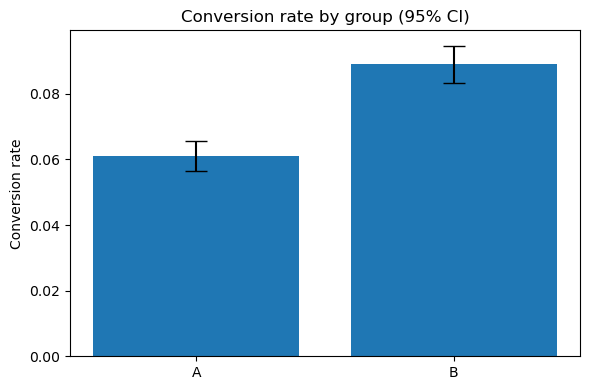

In [23]:
# Графік: Конверсія з 95% довірчими інтервалами
# Порівняння "середніх" конверсій + 95% Cl
z_crit = 1.96

def ci_95(x, n):
    p = x / n
    se = sqrt(p * (1 - p) / n)
    return p, p - z_crit * se, p + z_crit * se

pA, loA, hiA = ci_95(x_A, n_A)
pB, loB, hiB = ci_95(x_B, n_B)

means = [pA, pB]
yerr = np.array([[pA - loA, pB - loB], [hiA - pA, hiB - pB]])

plt.figure(figsize=(6,4))
plt.bar(["A", "B"], means, yerr=yerr, capsize=8)
plt.ylabel("Conversion rate")
plt.title("Conversion rate by group (95% CI)")
plt.tight_layout()
plt.savefig("cr_with_ci.png", dpi=200)
plt.show()

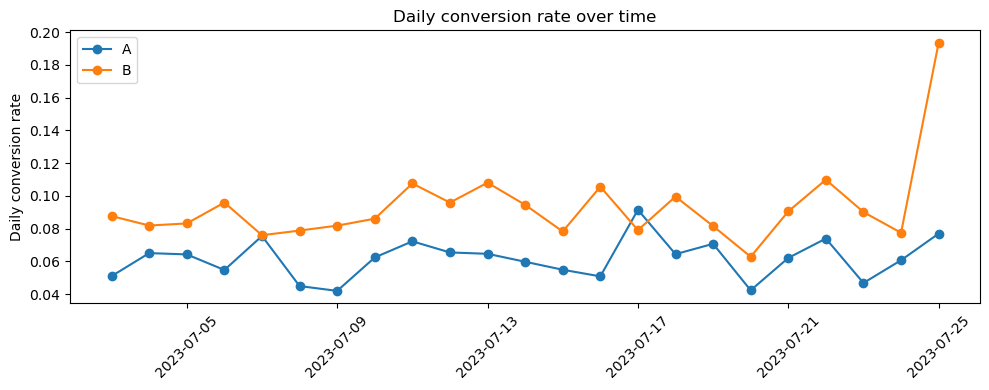

In [24]:
# Графік конверсії в часі
# Денна конверсія. Показує, як конверсія змінювалась щодня, і чи не було "дивних стрибків".
df["date"] = df["timestamp"].dt.date

daily = (df.groupby(["date", "test_group"])
           .agg(users=("user_id", "nunique"),
                conversions=("conversion", "sum"))
        )
daily["cr"] = daily["conversions"] / daily["users"]
daily = daily.reset_index()

plt.figure(figsize=(10,4))
for g in ["A", "B"]:
    tmp = daily[daily["test_group"] == g]
    plt.plot(tmp["date"], tmp["cr"], marker="o", label=g)

plt.ylabel("Daily conversion rate")
plt.title("Daily conversion rate over time")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("cr_over_time.png", dpi=200)
plt.show()

Висновки та рішення

- Конверсія в групі А : 6,10%
- Конверсія в групі В : 8,90%
- Різниця (uplift) : +2,80 процентних пунктів

Статистичний тест : two-proportion, z-test p_value = 5.48e- 14

Оскільки p_value < 0,05, ми відхтляємо нульову гіпотезу. Різниця між групами статистично значуща.

Рішення

Впроваджуємо варіант В , оскільки:
- конверсія суттєво вища,
- результат статистично значущий,
- денна динаміка стабільна.

  Новий дизайн з повідомленням про знижку 50% підвищує конверсію та рекомендований до повного rollout.